# Q1 Part 3 — SOR convergence acceleration  (spec A.3)
1. Iterations to converge vs ω at fixed grid.
2. Optimal ω vs grid resolution, compared with Poisson theory.
3. Estimated spectral radius vs ω.

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from utils_final import solve_potential, omega_opt_theory

def hist_arrays(info):
    h = info["hist"]
    return (np.array([r["it"]  for r in h]),
            np.array([r["res"] for r in h]),
            np.array([r["upd"] for r in h]),
            np.array([r["time"] for r in h]),
            np.array([r.get("rho_est", np.nan) for r in h]))

TOL_RES = 1e-5
TOL_UPD = 1e-5
MAX_ITER = 30000
CHECK = 200

eps, M = 0.01, 0.1
q, s, r = 4.0, 4.0, 4.0

In [138]:
# ═══════════════════════════════════════
# (i) Iterations vs ω, fixed 161 × 81
# ═══════════════════════════════════════
Nx, Ny = 161, 81
omegas = np.arange(1.0, 1.99, 0.05)   # fine sweep

omega_ok, iters_ok, time_ok, rho_ok = [], [], [], []

for w in omegas:
    _, _, _, info = solve_potential(
        eps=eps, M=M, q=q, s=s, r=r, Nx=Nx, Ny=Ny,
        method="sor", omega=float(w),
        tol_res=TOL_RES, tol_upd=TOL_UPD,
        max_iter=MAX_ITER, check_every=CHECK, verbose=False,
    )
    if info["converged"]:
        omega_ok.append(float(w))
        iters_ok.append(info["iters"])
        time_ok.append(info["seconds"])
        # average spectral-radius estimate from last few checks
        rhos = [h["rho_est"] for h in info["hist"][-5:] if not np.isnan(h.get("rho_est", np.nan))]
        rho_ok.append(np.mean(rhos) if rhos else np.nan)
        print(f"  ω={w:.2f}  iters={info['iters']:5d}  time={info['seconds']:.2f}s  ρ≈{rho_ok[-1]:.4f}")
    else:
        print(f"  ω={w:.2f}  DID NOT CONVERGE")

omega_ok = np.array(omega_ok)
iters_ok = np.array(iters_ok)
rho_ok   = np.array(rho_ok)

w_opt_emp = float(omega_ok[np.argmin(iters_ok)])
w_opt_th  = omega_opt_theory(Nx, Ny)
print(f"\nEmpirical ω_opt = {w_opt_emp:.2f}   Theory ω_opt = {w_opt_th:.4f}")

  ω=1.00  iters=22600  time=4.51s  ρ≈0.9998
  ω=1.05  iters=20600  time=3.89s  ρ≈0.9998
  ω=1.10  iters=19000  time=3.72s  ρ≈0.9998
  ω=1.15  iters=17400  time=3.46s  ρ≈0.9997
  ω=1.20  iters=16000  time=3.19s  ρ≈0.9997
  ω=1.25  iters=14600  time=2.88s  ρ≈0.9997
  ω=1.30  iters=13400  time=2.64s  ρ≈0.9997
  ω=1.35  iters=12200  time=2.41s  ρ≈0.9996
  ω=1.40  iters=11000  time=2.14s  ρ≈0.9996
  ω=1.45  iters=10000  time=2.01s  ρ≈0.9995
  ω=1.50  iters= 9000  time=1.82s  ρ≈0.9995
  ω=1.55  iters= 8200  time=1.62s  ρ≈0.9994
  ω=1.60  iters= 7200  time=1.44s  ρ≈0.9993
  ω=1.65  iters= 6400  time=1.30s  ρ≈0.9992
  ω=1.70  iters= 5600  time=1.14s  ρ≈0.9990
  ω=1.75  iters= 4800  time=0.93s  ρ≈0.9988
  ω=1.80  iters= 4000  time=0.79s  ρ≈0.9985
  ω=1.85  iters= 3200  time=0.62s  ρ≈0.9981
  ω=1.90  iters= 2400  time=0.47s  ρ≈0.9973
  ω=1.95  iters= 1600  time=0.31s  ρ≈0.9957

Empirical ω_opt = 1.95   Theory ω_opt = 1.9398


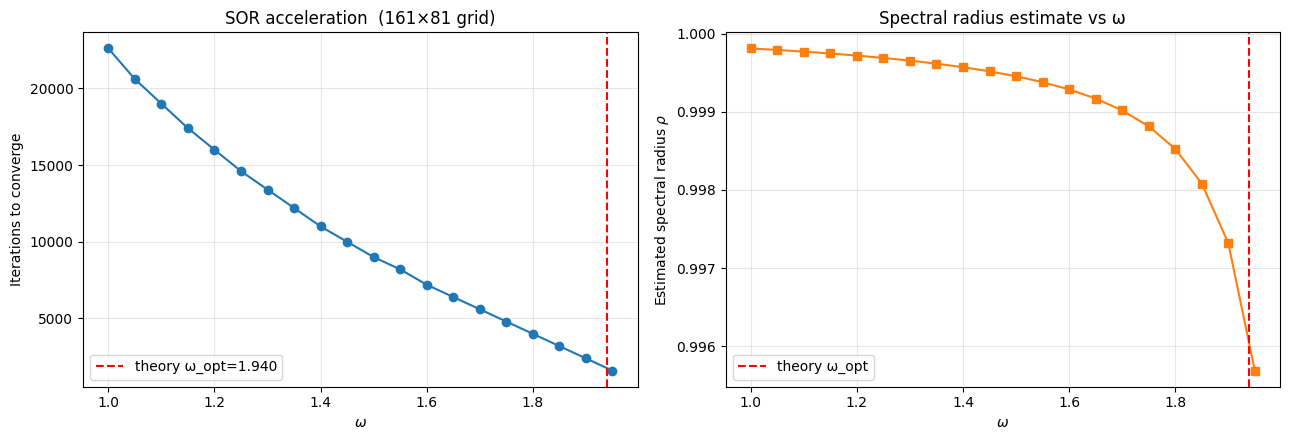

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# iterations vs ω
axes[0].plot(omega_ok, iters_ok, "o-")
axes[0].axvline(w_opt_th, color="r", ls="--", label=f"theory ω_opt={w_opt_th:.3f}")
axes[0].set_xlabel(r"$\omega$"); axes[0].set_ylabel("Iterations to converge")
axes[0].set_title(f"SOR acceleration  ({Nx}×{Ny} grid)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# spectral radius vs ω
axes[1].plot(omega_ok, rho_ok, "s-", color="C1")
axes[1].axvline(w_opt_th, color="r", ls="--", label=f"theory ω_opt")
axes[1].set_xlabel(r"$\omega$"); axes[1].set_ylabel(r"Estimated spectral radius $\rho$")
axes[1].set_title("Spectral radius estimate vs ω")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [125]:
# ═══════════════════════════════════════
# (ii) ω_opt vs grid resolution
# ═══════════════════════════════════════
grid_list = [(81, 41), (121, 61), (161, 81), (201, 101), (241, 121)]
omega_scan = np.arange(1.5, 1.99, 0.02)   # fine near the expected optimal

N_eff_list, w_num_list, w_th_list = [], [], []

for Nx_i, Ny_i in grid_list:
    best_w, best_it = None, None
    for w in omega_scan:
        _, _, _, info = solve_potential(
            eps=eps, M=M, q=q, s=s, r=r, Nx=Nx_i, Ny=Ny_i,
            method="sor", omega=float(w),
            tol_res=TOL_RES, tol_upd=TOL_UPD,
            max_iter=MAX_ITER, check_every=CHECK, verbose=False,
        )
        if info["converged"] and (best_it is None or info["iters"] < best_it):
            best_it = info["iters"]
            best_w = float(w)
    w_th = omega_opt_theory(Nx_i, Ny_i)
    N_eff_list.append(max(Nx_i, Ny_i))
    w_num_list.append(best_w if best_w else np.nan)
    w_th_list.append(w_th)
    print(f"  {Nx_i}×{Ny_i}  ω_opt(num)={best_w}  ω_opt(theory)={w_th:.4f}")

N_eff = np.array(N_eff_list, dtype=float)
w_num = np.array(w_num_list)
w_th  = np.array(w_th_list)

  81×41  ω_opt(num)=1.9800000000000004  ω_opt(theory)=1.8832
  121×61  ω_opt(num)=1.9800000000000004  ω_opt(theory)=1.9205
  161×81  ω_opt(num)=1.9800000000000004  ω_opt(theory)=1.9398
  201×101  ω_opt(num)=1.9800000000000004  ω_opt(theory)=1.9515
  241×121  ω_opt(num)=1.9800000000000004  ω_opt(theory)=1.9594


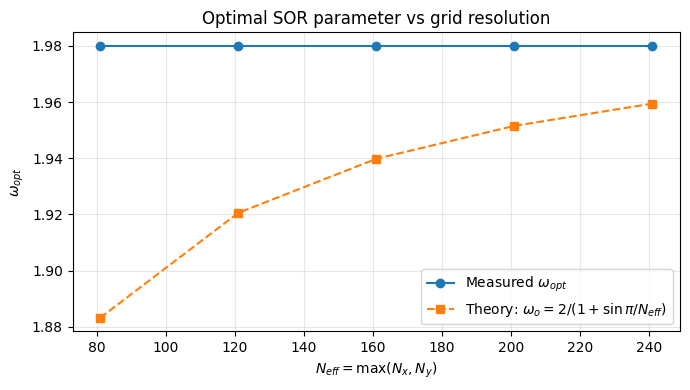

In [127]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(N_eff, w_num, "o-", label=r"Measured $\omega_{opt}$")
ax.plot(N_eff, w_th,  "s--", label=r"Theory: $\omega_o = 2/(1+\sin\pi/N_{eff})$")
ax.set_xlabel(r"$N_{eff} = \max(N_x, N_y)$")
ax.set_ylabel(r"$\omega_{opt}$")
ax.set_title(r"Optimal SOR parameter vs grid resolution")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

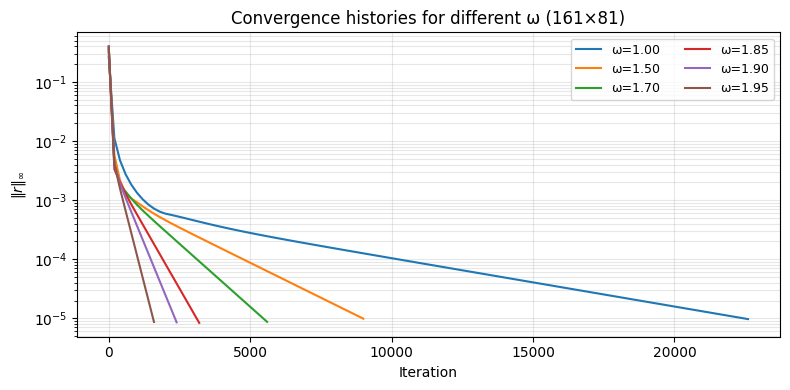

In [137]:
# ═══════════════════════════════════════
# (iii) Convergence histories for a few ω values (overlay)
# ═══════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 4))
for w in [1.0, 1.5, 1.7, 1.85, 1.9, 1.95]:
    _, _, _, info = solve_potential(
        eps=eps, M=M, q=q, s=s, r=r, Nx=161, Ny=81,
        method="sor", omega=float(w),
        tol_res=TOL_RES, tol_upd=TOL_UPD,
        max_iter=MAX_ITER, check_every=CHECK, verbose=False,
    )
    it, res, upd, t, rho = hist_arrays(info)
    label = f"ω={w:.2f}" + ("" if info["converged"] else " ✗")
    ax.semilogy(it, res, label=label)

ax.set_xlabel("Iteration"); ax.set_ylabel(r"$\|r\|_\infty$")
ax.set_title("Convergence histories for different ω (161×81)")
ax.legend(ncol=2, fontsize=9); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()